## Phase 1: Run Linear Probes on Single Datasets: Mistral-7B on Trivia-QA (2k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240505_151601-424bo6rg/files')  # path for mistral-7b on trivia_qa (2k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-vr_1ntuz because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## Utility Functions

In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [3]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([2.1640, 0.6109, 1.8344,  ..., 2.1640, 1.8344, 0.5004])


In [4]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

In [5]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
ca_entropy = entropy.to(torch.float32)
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.0165) tensor(0.7894)
torch.Size([2000, 33, 4096]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [6]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4096])


In [7]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [8]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [9]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

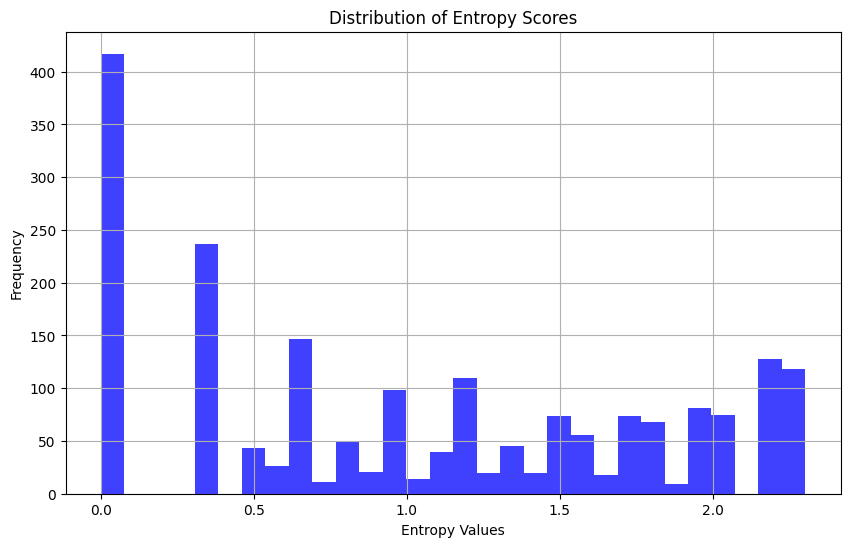

In [10]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.0698880379181435

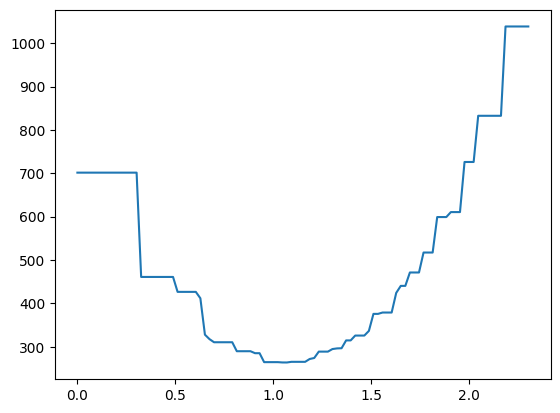

In [11]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [12]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

# bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.5250


In [13]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [14]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5694, AUROC: 0.6353
Training Loss: 0.6765, Validation Loss: 0.6818
Test Loss: 0.6909, Test Accuracy: 0.5000, AUROC: 0.5874
Training on Dataset 2/33
Validation Accuracy: 0.6611, AUROC: 0.6637
Training Loss: 0.6518, Validation Loss: 0.6637
Test Loss: 0.6744, Test Accuracy: 0.6200, AUROC: 0.6510
Training on Dataset 3/33
Validation Accuracy: 0.6611, AUROC: 0.6662
Training Loss: 0.6151, Validation Loss: 0.6487
Test Loss: 0.6566, Test Accuracy: 0.6500, AUROC: 0.6735
Training on Dataset 4/33
Validation Accuracy: 0.6583, AUROC: 0.6772
Training Loss: 0.5728, Validation Loss: 0.6368
Test Loss: 0.6445, Test Accuracy: 0.6500, AUROC: 0.6927
Training on Dataset 5/33
Validation Accuracy: 0.6722, AUROC: 0.6969
Training Loss: 0.5297, Validation Loss: 0.6284
Test Loss: 0.6195, Test Accuracy: 0.6600, AUROC: 0.7384
Training on Dataset 6/33
Validation Accuracy: 0.6556, AUROC: 0.7165
Training Loss: 0.4839, Validation Loss: 0.6146
Test Loss: 0.5962, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.8408
Training Loss: 0.1027, Validation Loss: 0.5542
Test Loss: 0.6424, Test Accuracy: 0.7400, AUROC: 0.8192
Training on Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7222, AUROC: 0.8251
Training Loss: 0.0774, Validation Loss: 0.6321
Test Loss: 0.6910, Test Accuracy: 0.7450, AUROC: 0.8150
Training on Dataset 21/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7417, AUROC: 0.8171
Training Loss: 0.0538, Validation Loss: 0.7348
Test Loss: 0.7842, Test Accuracy: 0.7300, AUROC: 0.7999
Training on Dataset 22/33
Validation Accuracy: 0.7333, AUROC: 0.8158
Training Loss: 0.0406, Validation Loss: 0.7617
Test Loss: 0.8013, Test Accuracy: 0.7400, AUROC: 0.8048
Training on Dataset 23/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7528, AUROC: 0.8222
Training Loss: 0.0329, Validation Loss: 0.7694
Test Loss: 0.8967, Test Accuracy: 0.7100, AUROC: 0.7884
Training on Dataset 24/33
Validation Accuracy: 0.7694, AUROC: 0.8184
Training Loss: 0.0291, Validation Loss: 0.8045
Test Loss: 0.9315, Test Accuracy: 0.6850, AUROC: 0.7785
Training on Dataset 25/33
Validation Accuracy: 0.7278, AUROC: 0.8102
Training Loss: 0.0260, Validation Loss: 0.8103
Test Loss: 0.9233, Test Accuracy: 0.7000, AUROC: 0.7825
Training on Dataset 26/33
Validation Accuracy: 0.7389, AUROC: 0.7982
Training Loss: 0.0233, Validation Loss: 0.9018
Test Loss: 0.9116, Test Accuracy: 0.7100, AUROC: 0.7892
Training on Dataset 27/33
Validation Accuracy: 0.7083, AUROC: 0.8020
Training Loss: 0.0216, Validation Loss: 0.9226
Test Loss: 0.9842, Test Accuracy: 0.7150, AUROC: 0.7853
Training on Dataset 28/33
Validation Accuracy: 0.7472, AUROC: 0.8131
Training Loss: 0.0202, Validation Loss: 0.8861
Test Loss: 1.0270, Test Accuracy: 0.6950, AUROC: 0

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.8446 at layer 33


In [17]:
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests):
    X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
    X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_train_cc = y_trains[layer_range[0]]
    y_val_cc = y_vals[layer_range[0]]
    y_test_cc = y_tests[layer_range[0]]
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

In [18]:
# Save models for testing on Accuracy
tblr_best_auc_indices = np.argsort(tblr_test_aucs)[::-1]

topktblr_test_accs = {}
topktblr_test_aucs = {}
topktblr_models = {}

for top_k in range(1, 10):
    indices = tblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktblr_test_accs[tuple(indices)] = test_acc
    topktblr_test_aucs[tuple(indices)] = test_auc
    topktblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [33]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.8058
Training Loss: 0.0083, Validation Loss: 2.1718
Test Loss: 1.8016, Test Accuracy: 0.7550, AUROC: 0.8446
Training on top-2 Datasets indexed [33, 31]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7222, AUROC: 0.8077
Training Loss: 0.0084, Validation Loss: 2.2132
Test Loss: 1.8595, Test Accuracy: 0.7550, AUROC: 0.8440
Training on top-3 Datasets indexed [33, 31, 32]


...

Validation Accuracy: 0.7306, AUROC: 0.8071
Training Loss: 0.0084, Validation Loss: 2.1526
Test Loss: 1.7937, Test Accuracy: 0.7550, AUROC: 0.8444
Training on top-8 Datasets indexed [33, 31, 32, 14, 19, 29, 16, 13]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.8076
Training Loss: 0.0083, Validation Loss: 2.2237
Test Loss: 1.8678, Test Accuracy: 0.7600, AUROC: 0.8441
Training on top-9 Datasets indexed [33, 31, 32, 14, 19, 29, 16, 13, 17]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.8082
Training Loss: 0.0082, Validation Loss: 2.4369
Test Loss: 2.0713, Test Accuracy: 0.7550, AUROC: 0.8433


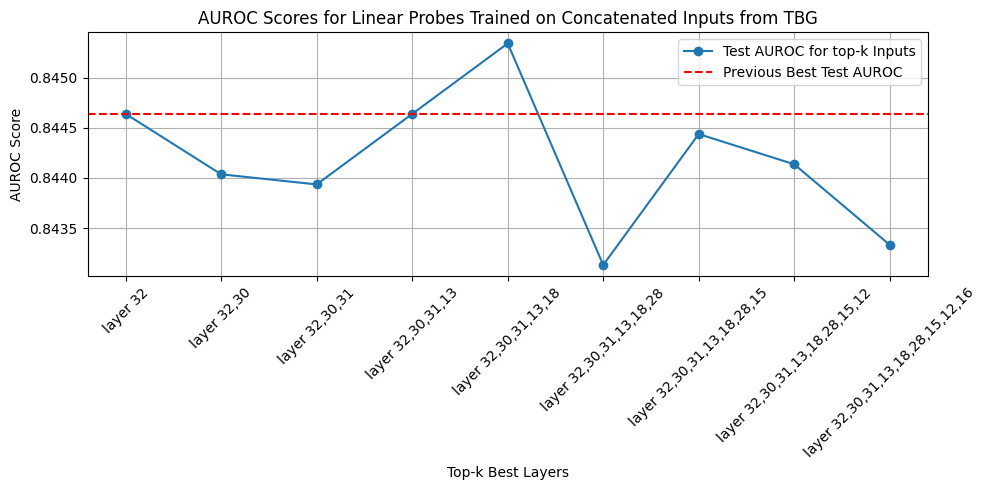

In [19]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(tblr_test_aucs), topktblr_test_aucs, 'TBG')

### Explore Second Last generated Token (SLT)


In [20]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4096])


In [21]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4096])

In [22]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4096]) torch.float32


In [23]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [24]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5389, AUROC: 0.5000
Training Loss: 0.6914, Validation Loss: 0.6903
Test Loss: 0.6991, Test Accuracy: 0.4650, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.5389, AUROC: 0.5890
Training Loss: 0.6914, Validation Loss: 0.6903
Test Loss: 0.6991, Test Accuracy: 0.4650, AUROC: 0.6131
Training on Dataset 3/33
Validation Accuracy: 0.5333, AUROC: 0.5790
Training Loss: 0.6879, Validation Loss: 0.6883
Test Loss: 0.6935, Test Accuracy: 0.4800, AUROC: 0.6423
Training on Dataset 4/33
Validation Accuracy: 0.5639, AUROC: 0.6037
Training Loss: 0.6779, Validation Loss: 0.6828
Test Loss: 0.6864, Test Accuracy: 0.5650, AUROC: 0.6540
Training on Dataset 5/33
Validation Accuracy: 0.6000, AUROC: 0.6305
Training Loss: 0.6612, Validation Loss: 0.6718
Test Loss: 0.6730, Test Accuracy: 0.6000, AUROC: 0.6687
Training on Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6550
Training Loss: 0.6342, Validation Loss: 0.6562
Test Loss: 0.6507, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.8364 at layer 31


In [26]:
# Select best top-k layers 
sblr_best_auc_indices = np.argsort(sblr_test_aucs)[::-1]

topksblr_test_accs = {}
topksblr_test_aucs = {}
topksblr_models = {}

for top_k in range(1, 10):
    indices = sblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksblr_test_accs[tuple(indices)] = test_acc
    topksblr_test_aucs[tuple(indices)] = test_auc
    topksblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [31]
Validation Accuracy: 0.7722, AUROC: 0.8602
Training Loss: 0.0133, Validation Loss: 0.7615
Test Loss: 0.9075, Test Accuracy: 0.7550, AUROC: 0.8364
Training on top-2 Datasets indexed [31, 33]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7694, AUROC: 0.8614
Training Loss: 0.0083, Validation Loss: 1.6512
Test Loss: 1.8784, Test Accuracy: 0.7550, AUROC: 0.8366
Training on top-3 Datasets indexed [31, 33, 32]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7722, AUROC: 0.8620
Training Loss: 0.0082, Validation Loss: 1.6787
Test Loss: 1.8975, Test Accuracy: 0.7600, AUROC: 0.8367
Training on top-4 Datasets indexed [31, 33, 32, 14]


...

Validation Accuracy: 0.7722, AUROC: 0.8635
Training Loss: 0.0082, Validation Loss: 1.6441
Test Loss: 1.9043, Test Accuracy: 0.7500, AUROC: 0.8374
Training on top-8 Datasets indexed [31, 33, 32, 14, 29, 30, 13, 11]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7722, AUROC: 0.8621
Training Loss: 0.0083, Validation Loss: 1.5743
Test Loss: 1.8128, Test Accuracy: 0.7500, AUROC: 0.8368
Training on top-9 Datasets indexed [31, 33, 32, 14, 29, 30, 13, 11, 18]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7694, AUROC: 0.8614
Training Loss: 0.0082, Validation Loss: 1.6706
Test Loss: 1.8937, Test Accuracy: 0.7550, AUROC: 0.8368


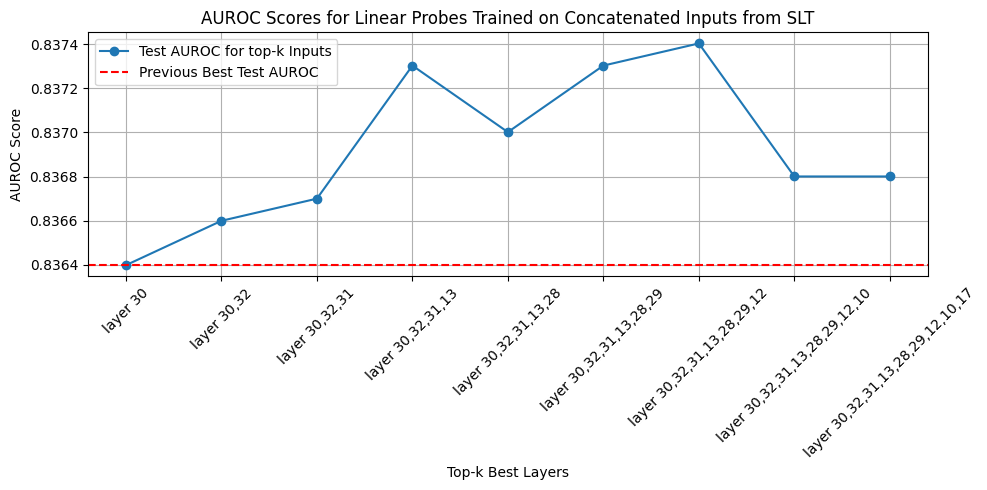

In [31]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(sblr_test_aucs), topksblr_test_aucs, 'SLT')

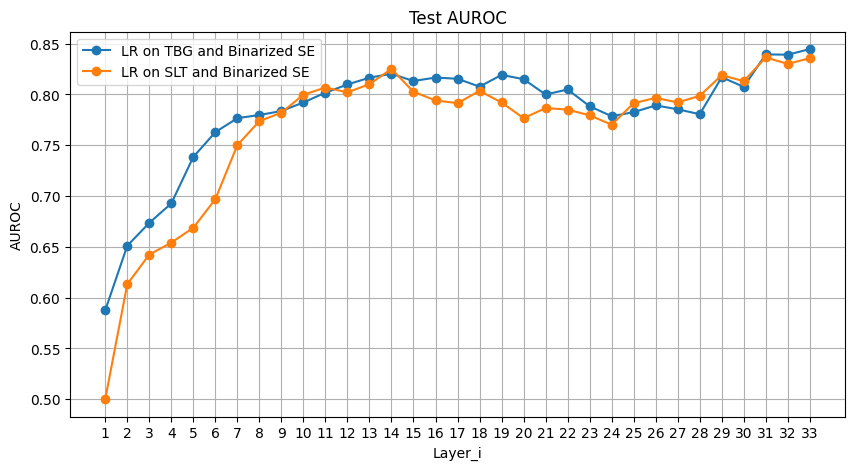

TBG: max AUROC for LR trained and tested on Binarized SE: 0.8446 at 33 layer
SLT: max AUROC for LR trained and tested on Binarized SE: 0.8364 at 31 layer


In [28]:
plot_1d_metrics([tblr_test_aucs, sblr_test_aucs], ['LR on TBG and Binarized SE', 'LR on SLT and Binarized SE'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Binarized SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binarized SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [32]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])


In [33]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [34]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.5550


In [35]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.5194, AUROC: 0.5786
Training Loss: 0.6845, Validation Loss: 0.6887
Test Loss: 0.6859, Test Accuracy: 0.5350, AUROC: 0.5906
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.5694, AUROC: 0.5849
Training Loss: 0.6682, Validation Loss: 0.6839
Test Loss: 0.6800, Test Accuracy: 0.5600, AUROC: 0.5988
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.5806, AUROC: 0.6003
Training Loss: 0.6368, Validation Loss: 0.6759
Test Loss: 0.6672, Test Accuracy: 0.5950, AUROC: 0.6334
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.5972, AUROC: 0.6176
Training Loss: 0.5961, Validation Loss: 0.6676
Test Loss: 0.6580, Test Accuracy: 0.6050, AUROC: 0.6242
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.6056, AUROC: 0.6577
Training Loss: 0.5562, Validation Loss: 0.6520
Test Loss: 0.6479, Test Accuracy: 0.6450, AUROC: 0.6590
Training on TBG-Acc Dataset 6/33
Validation Accuracy: 0.6278, AUROC: 0.6933
Training Loss: 0.5152, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.8026
Training Loss: 0.2031, Validation Loss: 0.5789
Test Loss: 0.6478, Test Accuracy: 0.7100, AUROC: 0.7537
Training on TBG-Acc Dataset 17/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.8020
Training Loss: 0.1677, Validation Loss: 0.5968
Test Loss: 0.6840, Test Accuracy: 0.6700, AUROC: 0.7449
Training on TBG-Acc Dataset 18/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.7885
Training Loss: 0.1262, Validation Loss: 0.6699
Test Loss: 0.7562, Test Accuracy: 0.6700, AUROC: 0.7243
Training on TBG-Acc Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.7798
Training Loss: 0.0923, Validation Loss: 0.7406
Test Loss: 0.8006, Test Accuracy: 0.6900, AUROC: 0.7364
Training on TBG-Acc Dataset 21/33
Validation Accuracy: 0.7333, AUROC: 0.7900
Training Loss: 0.0625, Validation Loss: 0.7527
Test Loss: 0.9969, Test Accuracy: 0.6350, AUROC: 0.7021
Training on TBG-Acc Dataset 22/33
Validation Accuracy: 0.7417, AUROC: 0.7821
Training Loss: 0.0454, Validation Loss: 0.7995
Test Loss: 1.1456, Test Accuracy: 0.6550, AUROC: 0.6965
Training on TBG-Acc Dataset 23/33
Validation Accuracy: 0.7278, AUROC: 0.7942
Training Loss: 0.0348, Validation Loss: 0.7946
Test Loss: 1.1940, Test Accuracy: 0.6450, AUROC: 0.6964
Training on TBG-Acc Dataset 24/33
Validation Accuracy: 0.7278, AUROC: 0.7989
Training Loss: 0.0289, Validation Loss: 0.8082
Test Loss: 1.1751, Test Accuracy: 0.6600, AUROC: 0.7021
Training on TBG-Acc Dataset 25/33
Validation Accuracy: 0.7361, AUROC: 0.7902
Training Loss: 0.0255, Validation Loss: 0.8532
Test Loss:

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


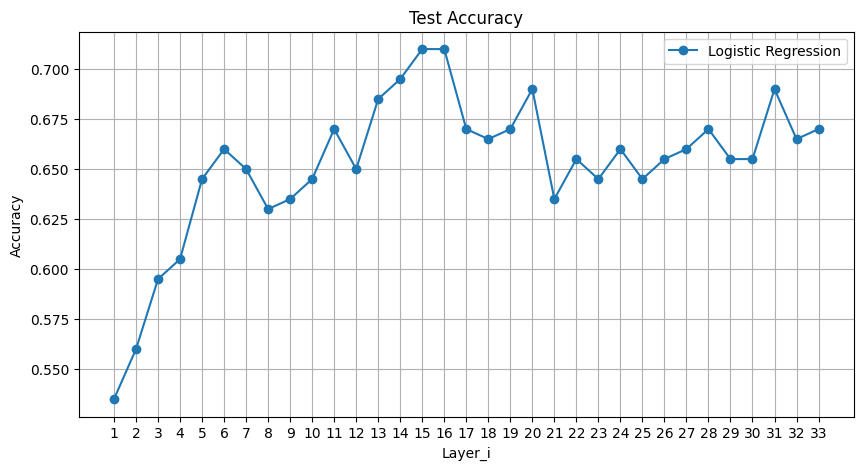

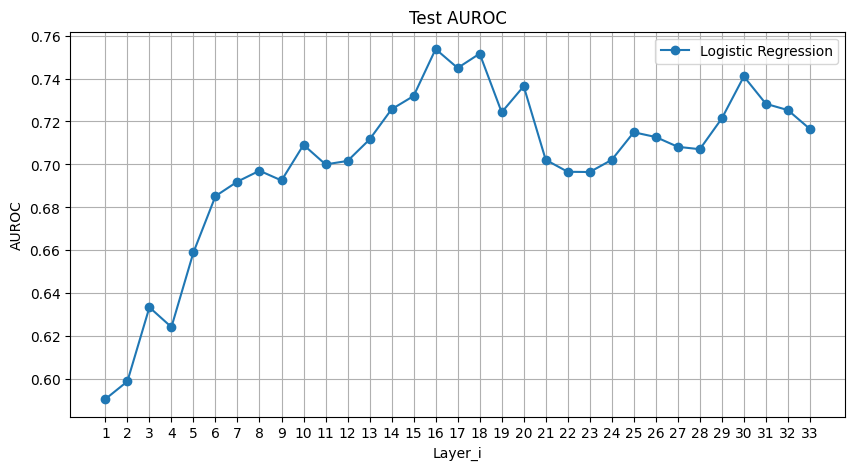

In [36]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [37]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.7537 at layer 16


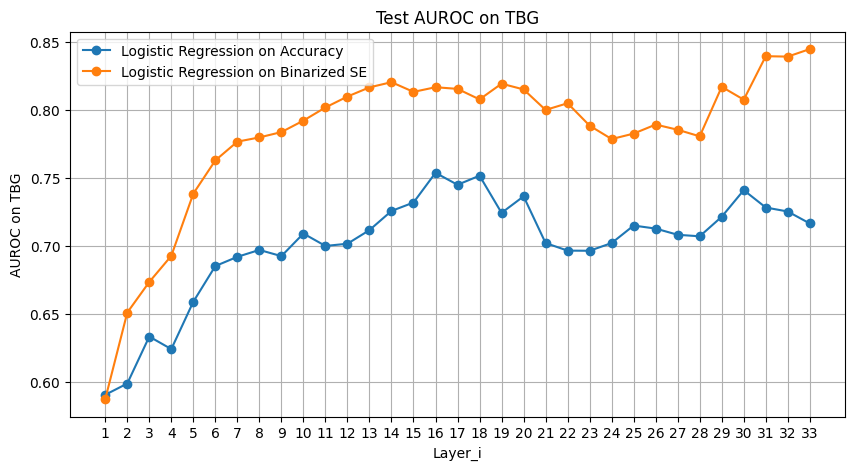

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7537 at 16 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8446 at 33 layer


In [38]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [39]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [40]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.5222, AUROC: 0.5000
Training Loss: 0.6924, Validation Loss: 0.6922
Test Loss: 0.6896, Test Accuracy: 0.5550, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.5222, AUROC: 0.5977
Training Loss: 0.6924, Validation Loss: 0.6922
Test Loss: 0.6896, Test Accuracy: 0.5550, AUROC: 0.6091
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.5472, AUROC: 0.5368
Training Loss: 0.6892, Validation Loss: 0.6897
Test Loss: 0.6845, Test Accuracy: 0.5950, AUROC: 0.5982
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.5528, AUROC: 0.5994
Training Loss: 0.6820, Validation Loss: 0.6860
Test Loss: 0.6807, Test Accuracy: 0.5950, AUROC: 0.6150
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.5833, AUROC: 0.6284
Training Loss: 0.6708, Validation Loss: 0.6779
Test Loss: 0.6719, Test Accuracy: 0.5800, AUROC: 0.6343
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.6194, AUROC: 0.6528
Training Loss: 0.6486, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7444, AUROC: 0.7952
Training Loss: 0.1260, Validation Loss: 0.6542
Test Loss: 0.7438, Test Accuracy: 0.7150, AUROC: 0.7580
Training on SLT-Acc Dataset 21/33
Validation Accuracy: 0.7306, AUROC: 0.7765
Training Loss: 0.0802, Validation Loss: 0.7609
Test Loss: 0.8686, Test Accuracy: 0.6950, AUROC: 0.7448
Training on SLT-Acc Dataset 22/33
Validation Accuracy: 0.7333, AUROC: 0.7843
Training Loss: 0.0543, Validation Loss: 0.7925
Test Loss: 0.9578, Test Accuracy: 0.6850, AUROC: 0.7337
Training on SLT-Acc Dataset 23/33
Validation Accuracy: 0.7250, AUROC: 0.7757
Training Loss: 0.0402, Validation Loss: 0.8516
Test Loss: 1.0353, Test Accuracy: 0.6550, AUROC: 0.7179
Training on SLT-Acc Dataset 24/33
Validation Accuracy: 0.7639, AUROC: 0.7944
Training Loss: 0.0315, Validation Loss: 0.8539
Test Loss: 1.0958, Test Accuracy: 0.6650, AUROC: 0.7136
Training on SLT-Acc Dataset 25/33
Validation Accuracy: 0.7389, AUROC: 0.7898
Training Loss: 0.0259, Validation Loss: 0.9059
Test Loss:

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


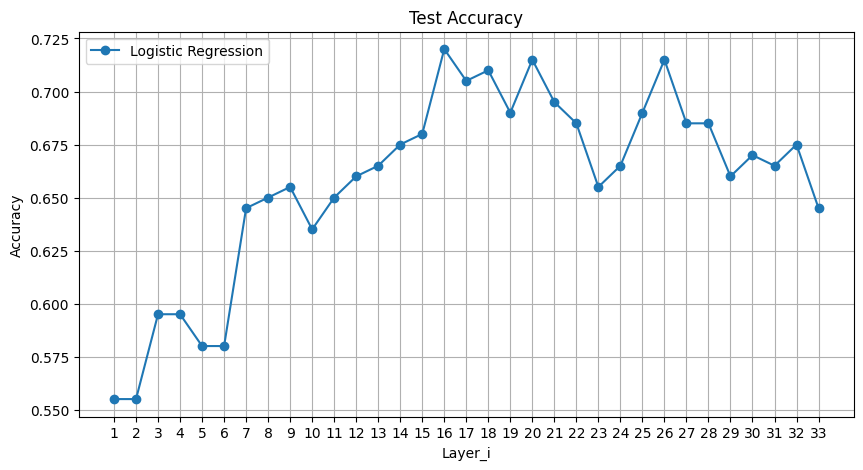

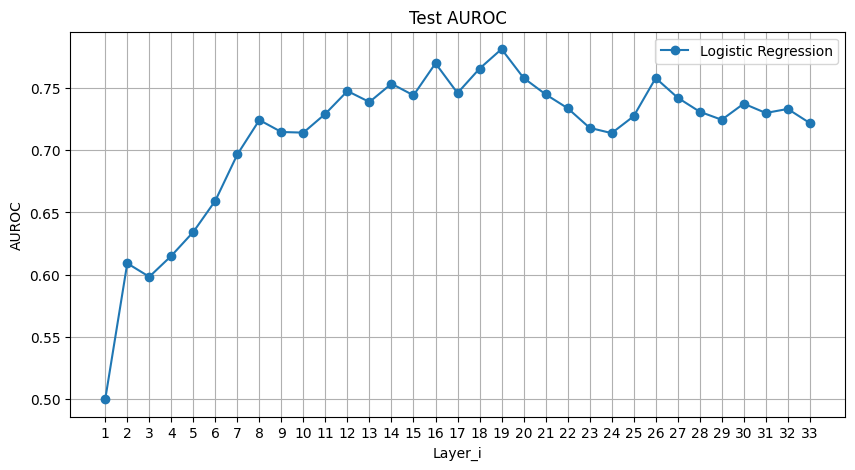

In [41]:
plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [42]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.7812 at layer 19


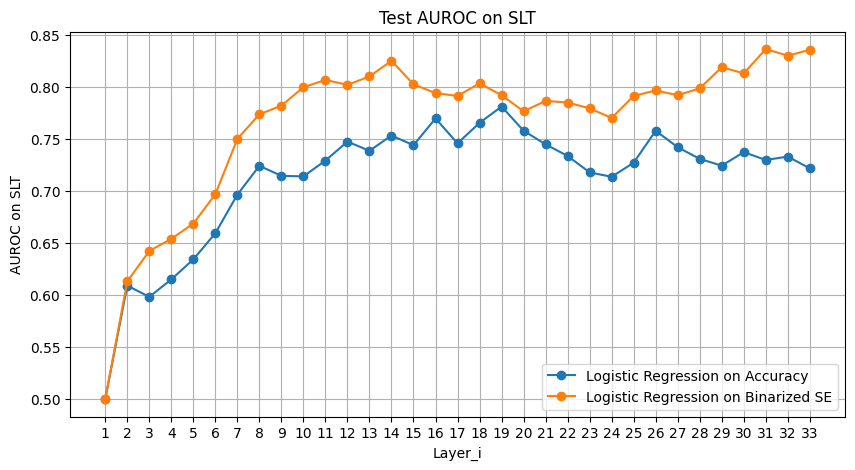

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7812 at 19 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8364 at 31 layer


In [43]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [44]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [45]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.5694, AUROC: 0.6353
Training Loss: 0.6765, Validation Loss: 0.6818
Test Loss: 0.6831, Test Accuracy: 0.5700, AUROC: 0.5713
Training on TBG Dataset 2/33
Validation Accuracy: 0.6611, AUROC: 0.6637
Training Loss: 0.6518, Validation Loss: 0.6637
Test Loss: 0.6749, Test Accuracy: 0.5800, AUROC: 0.6116
Training on TBG Dataset 3/33
Validation Accuracy: 0.6611, AUROC: 0.6662
Training Loss: 0.6151, Validation Loss: 0.6487
Test Loss: 0.6636, Test Accuracy: 0.6000, AUROC: 0.6207
Training on TBG Dataset 4/33
Validation Accuracy: 0.6583, AUROC: 0.6772
Training Loss: 0.5728, Validation Loss: 0.6368
Test Loss: 0.6572, Test Accuracy: 0.6200, AUROC: 0.6316
Training on TBG Dataset 5/33
Validation Accuracy: 0.6722, AUROC: 0.6969
Training Loss: 0.5297, Validation Loss: 0.6284
Test Loss: 0.6448, Test Accuracy: 0.6500, AUROC: 0.6464
Training on TBG Dataset 6/33
Validation Accuracy: 0.6556, AUROC: 0.7165
Training Loss: 0.4839, Validation Loss: 0.6146
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.8408
Training Loss: 0.1027, Validation Loss: 0.5542
Test Loss: 0.9178, Test Accuracy: 0.6300, AUROC: 0.7061
Training on TBG Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7222, AUROC: 0.8251
Training Loss: 0.0774, Validation Loss: 0.6321
Test Loss: 0.9414, Test Accuracy: 0.6550, AUROC: 0.7228
Training on TBG Dataset 21/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7417, AUROC: 0.8171
Training Loss: 0.0538, Validation Loss: 0.7348
Test Loss: 1.0676, Test Accuracy: 0.6500, AUROC: 0.7165
Training on TBG Dataset 22/33
Validation Accuracy: 0.7333, AUROC: 0.8158
Training Loss: 0.0406, Validation Loss: 0.7617
Test Loss: 1.1022, Test Accuracy: 0.6600, AUROC: 0.7145
Training on TBG Dataset 23/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7528, AUROC: 0.8222
Training Loss: 0.0329, Validation Loss: 0.7694
Test Loss: 1.1327, Test Accuracy: 0.6500, AUROC: 0.7222
Training on TBG Dataset 24/33
Validation Accuracy: 0.7694, AUROC: 0.8184
Training Loss: 0.0291, Validation Loss: 0.8045
Test Loss: 1.1630, Test Accuracy: 0.6350, AUROC: 0.7130
Training on TBG Dataset 25/33
Validation Accuracy: 0.7278, AUROC: 0.8102
Training Loss: 0.0260, Validation Loss: 0.8103
Test Loss: 1.2109, Test Accuracy: 0.6400, AUROC: 0.7057
Training on TBG Dataset 26/33
Validation Accuracy: 0.7389, AUROC: 0.7982
Training Loss: 0.0233, Validation Loss: 0.9018
Test Loss: 1.2638, Test Accuracy: 0.6300, AUROC: 0.6922
Training on TBG Dataset 27/33
Validation Accuracy: 0.7083, AUROC: 0.8020
Training Loss: 0.0216, Validation Loss: 0.9226
Test Loss: 1.3685, Test Accuracy: 0.6150, AUROC: 0.6949
Training on TBG Dataset 28/33
Validation Accuracy: 0.7472, AUROC: 0.8131
Training Loss: 0.0202, Validation Loss: 0.8861
Test Loss: 1.4300, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


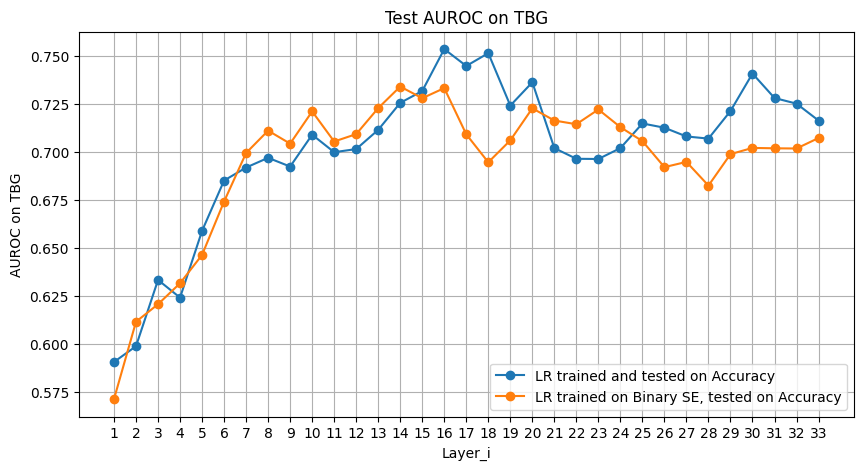

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7537 at 16 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7342 at 14 layer


In [47]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

In [48]:
## Use trained probes on concat-ed inputs of best layers
topktablr_test_accs = {}
topktablr_test_aucs = {}

for indices in topktblr_models.keys():
    print(f"Testing on top-{len(indices)} TBG Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topktblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktablr_test_accs[tuple(indices)] = test_acc
    topktablr_test_aucs[tuple(indices)] = test_auc

Testing on top-1 TBG Datasets trained probe: [32]
Test Loss: 3.5086, Test Accuracy: 0.6250, AUROC: 0.7074
Testing on top-2 TBG Datasets trained probe: [32, 30]
Test Loss: 3.6126, Test Accuracy: 0.6250, AUROC: 0.7082
Testing on top-3 TBG Datasets trained probe: [32, 30, 31]
Test Loss: 3.5084, Test Accuracy: 0.6250, AUROC: 0.7101
Testing on top-4 TBG Datasets trained probe: [32, 30, 31, 13]
Test Loss: 3.5364, Test Accuracy: 0.6300, AUROC: 0.7099
Testing on top-5 TBG Datasets trained probe: [32, 30, 31, 13, 18]
Test Loss: 3.6672, Test Accuracy: 0.6250, AUROC: 0.7063
Testing on top-6 TBG Datasets trained probe: [32, 30, 31, 13, 18, 28]
Test Loss: 3.7587, Test Accuracy: 0.6150, AUROC: 0.7073
Testing on top-7 TBG Datasets trained probe: [32, 30, 31, 13, 18, 28, 15]
Test Loss: 3.5050, Test Accuracy: 0.6250, AUROC: 0.7048
Testing on top-8 TBG Datasets trained probe: [32, 30, 31, 13, 18, 28, 15, 12]
Test Loss: 3.6310, Test Accuracy: 0.6200, AUROC: 0.7054
Testing on top-9 TBG Datasets trained pr

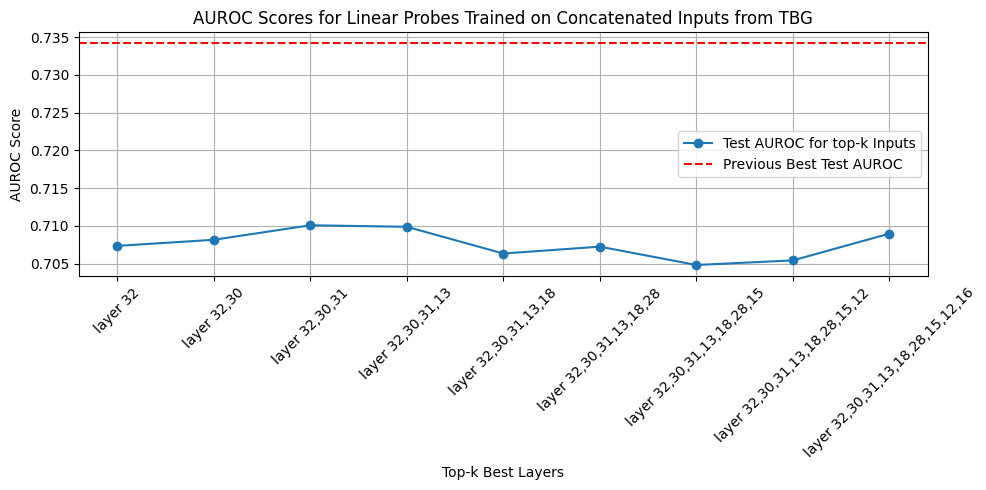

In [49]:
plot_metrics_w_constant(max(tablr_test_aucs), topktablr_test_aucs, 'TBG')

Now we test on SLT embeddings.

In [50]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [51]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.5389, AUROC: 0.5000
Training Loss: 0.6914, Validation Loss: 0.6903
Test Loss: 0.6884, Test Accuracy: 0.5550, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.5389, AUROC: 0.5890
Training Loss: 0.6914, Validation Loss: 0.6903
Test Loss: 0.6883, Test Accuracy: 0.5550, AUROC: 0.5983
Training on SLT Dataset 3/33
Validation Accuracy: 0.5333, AUROC: 0.5790
Training Loss: 0.6879, Validation Loss: 0.6883
Test Loss: 0.6838, Test Accuracy: 0.5700, AUROC: 0.6040
Training on SLT Dataset 4/33
Validation Accuracy: 0.5639, AUROC: 0.6037
Training Loss: 0.6779, Validation Loss: 0.6828
Test Loss: 0.6796, Test Accuracy: 0.6350, AUROC: 0.6159
Training on SLT Dataset 5/33
Validation Accuracy: 0.6000, AUROC: 0.6305
Training Loss: 0.6612, Validation Loss: 0.6718
Test Loss: 0.6689, Test Accuracy: 0.6300, AUROC: 0.6398
Training on SLT Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6550
Training Loss: 0.6342, Validation Loss: 0.6562
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


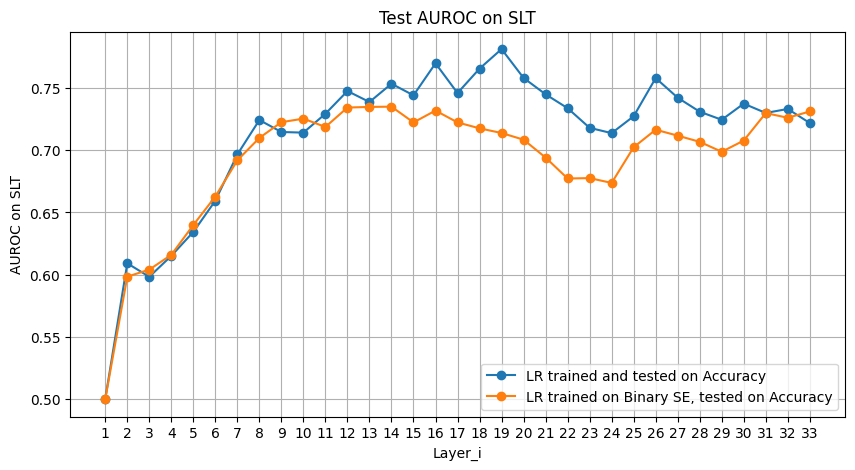

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7812 at 19 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7349 at 14 layer


In [52]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")

In [53]:
## Use trained probes on concat-ed inputs of best layers
topksablr_test_accs = {}
topksablr_test_aucs = {}

for indices in topksblr_models.keys():
    print(f"Testing on top-{len(indices)} SLT Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topksblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksablr_test_accs[tuple(indices)] = test_acc
    topksablr_test_aucs[tuple(indices)] = test_auc

# topksablr_test_aucs

Testing on top-1 SLT Datasets trained probe: [30]
Test Loss: 1.4581, Test Accuracy: 0.6550, AUROC: 0.7297
Testing on top-2 SLT Datasets trained probe: [30, 32]
Test Loss: 3.0965, Test Accuracy: 0.6550, AUROC: 0.7323
Testing on top-3 SLT Datasets trained probe: [30, 32, 31]
Test Loss: 3.1807, Test Accuracy: 0.6600, AUROC: 0.7297
Testing on top-4 SLT Datasets trained probe: [30, 32, 31, 13]
Test Loss: 3.2868, Test Accuracy: 0.6600, AUROC: 0.7309
Testing on top-5 SLT Datasets trained probe: [30, 32, 31, 13, 28]
Test Loss: 3.0133, Test Accuracy: 0.6550, AUROC: 0.7317
Testing on top-6 SLT Datasets trained probe: [30, 32, 31, 13, 28, 29]
Test Loss: 3.1204, Test Accuracy: 0.6550, AUROC: 0.7322
Testing on top-7 SLT Datasets trained probe: [30, 32, 31, 13, 28, 29, 12]
Test Loss: 3.1380, Test Accuracy: 0.6600, AUROC: 0.7297
Testing on top-8 SLT Datasets trained probe: [30, 32, 31, 13, 28, 29, 12, 10]
Test Loss: 3.0081, Test Accuracy: 0.6500, AUROC: 0.7294
Testing on top-9 SLT Datasets trained pr

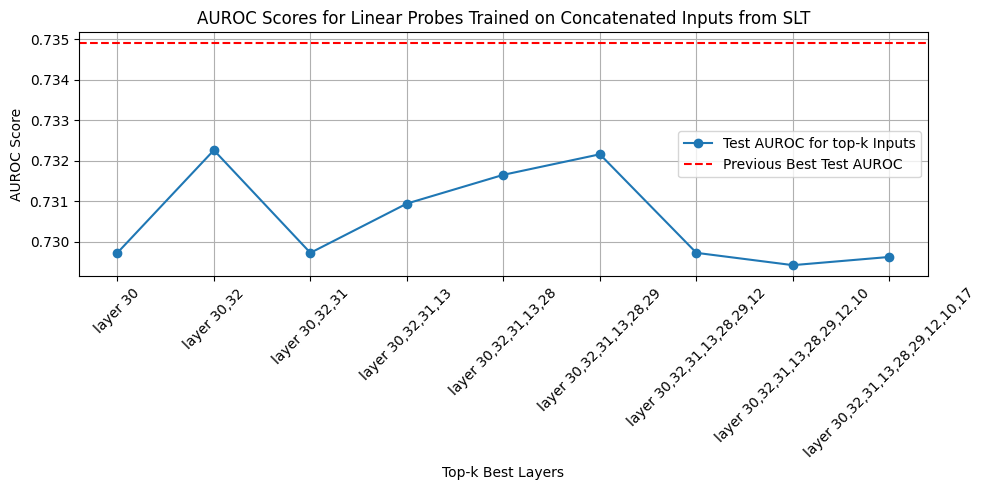

In [54]:
plot_metrics_w_constant(max(sablr_test_aucs), topksablr_test_aucs, 'SLT')

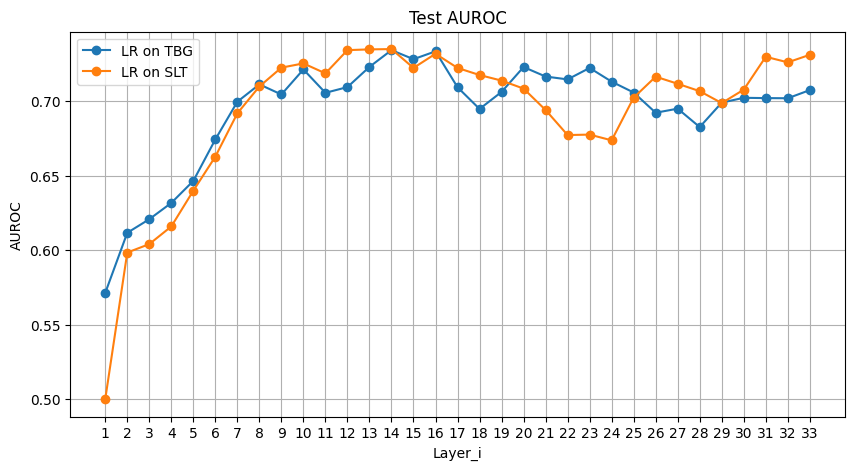

TBG: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7342 at 14 layer
SLT: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7349 at 14 layer


In [55]:
# Compare TBG and SLT at predicting Acc from probes trained on b-SE
plot_1d_metrics([tablr_test_aucs, sablr_test_aucs], ['LR on TBG', 'LR on SLT'], 'AUROC')
print(f"TBG: max AUROC for LR trained on b-SE and tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on b-SE and tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")